In [1]:
# These modules are required for loading and reading data.
from dysh.fits.gbtfitsload import GBTFITSLoad
from dysh.spectra.spectrum import Spectrum
from astropy import units as u
from dysh.log import init_logging

# We will use matplotlib for plotting.
import matplotlib.pyplot as plt

# These modules are used for file I/O
from dysh.util.files import dysh_data
from pathlib import Path

In [2]:
init_logging(2)

# also create a local "output" directory where temporary notebook files can be stored.
output_dir = Path.cwd() / "output"
output_dir.mkdir(exist_ok=True)

In [3]:
dysh_data(test="?")

# dysh_data::test
# ---------------
getps AGBT05B_047_01/AGBT05B_047_01.raw.acs/
getps2 TGBT21A_501_11/TGBT21A_501_11.raw.vegas.fits
getfs TGBT21A_504_01/TGBT21A_504_01.raw.vegas/TGBT21A_504_01.raw.vegas.A.fits
subbeamnod2 TRCO_230413_Ka


In [4]:
# filename = dysh_data(example="positionswitch/data/AGBT05B_047_01/AGBT05B_047_01.raw.acs/AGBT05B_047_01.raw.acs.fits")
# filename = dysh_data(example="getps")
filename = dysh_data(test="getps")

16:01:20.789 I Resolving test=getps -> AGBT05B_047_01/AGBT05B_047_01.raw.acs/


In [5]:
sdfits = GBTFITSLoad(filename)
sdfits.info()

16:01:20.893 I Index loaded from .index file (44/93 columns). Missing columns (TCAL, WCS, calibration metadata, etc.) will be automatically loaded from FITS file when first accessed.


Filename: /bigdisk/src/dysh/testdata/AGBT05B_047_01/AGBT05B_047_01.raw.acs/AGBT05B_047_01.raw.acs.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      12   ()      
  1  SINGLE DISH    1 BinTableHDU    229   352R x 70C   [32A, 1D, 22A, 1D, 1D, 1D, 32768E, 16A, 6A, 8A, 1D, 1D, 1D, 4A, 1D, 4A, 1D, 1I, 32A, 32A, 1J, 32A, 16A, 1E, 8A, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 8A, 1D, 1D, 12A, 1I, 1I, 1D, 1D, 1I, 1A, 1I, 1I, 16A, 16A, 1J, 1J, 22A, 1D, 1D, 1I, 1A, 1D, 1E, 1D, 1A, 1A, 8A, 1E, 1E, 16A, 1I, 1I, 1I]   


In [6]:
sdfits.summary()

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
51,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,198.3431,18.6427
52,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,198.9306,18.7872
53,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,199.3305,18.3561
54,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,199.9157,18.4927
55,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,200.3042,18.0575
56,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,200.8906,18.1860
57,NGC5291,4386.0,OnOff,1,1.420405,1,2,11,1,202.3275,17.3853
58,NGC5291,4386.0,OnOff,2,1.420405,1,2,11,1,202.9192,17.4949


In [7]:
ps_scan_block = sdfits.getps(scan=51, ifnum=0, plnum=0, fdnum=0)

In [8]:
print(f"Number of integrations = {ps_scan_block[0].nrows}")

Number of integrations = 22


In [9]:
ta = ps_scan_block.timeaverage()

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


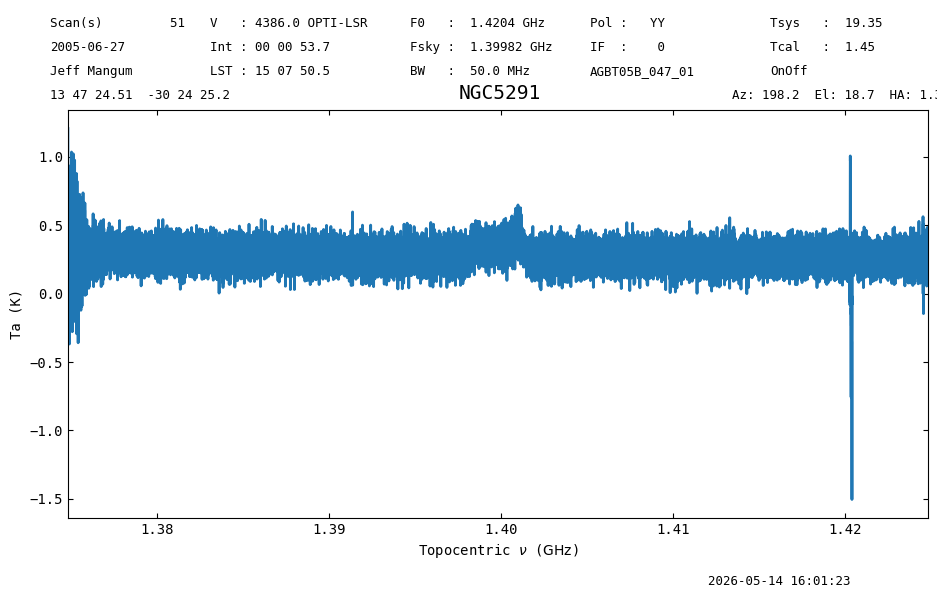

In [10]:
ta.plot();

In [11]:
# Define the formats in a list.
fmt = [ 
    "basic",
    "commented_header",
    "ecsv",
    "fixed_width",
    "ipac",
    "mrt",
    "votable",
]


# Loop over formats writing the calibrated spectrum.
for f in fmt:
    file = output_dir / f"testwrite.{f}"
    ta.write(file, format=f, overwrite=True)

In [12]:
ta.write(output_dir / "testwrite.fits", format="fits", overwrite=True)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


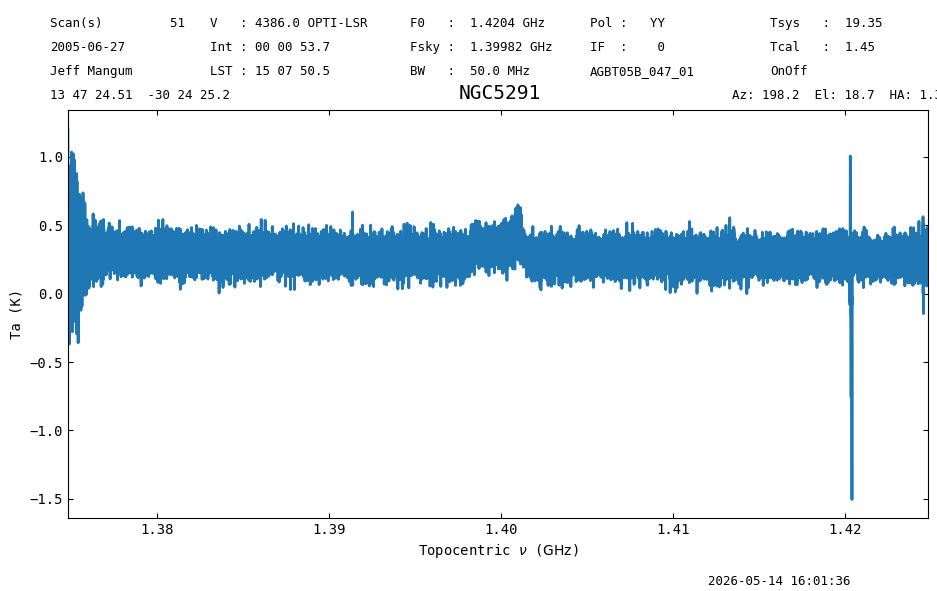

In [13]:
s1 = Spectrum.read(output_dir / "testwrite.fits", format="fits")
s1.plot();

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


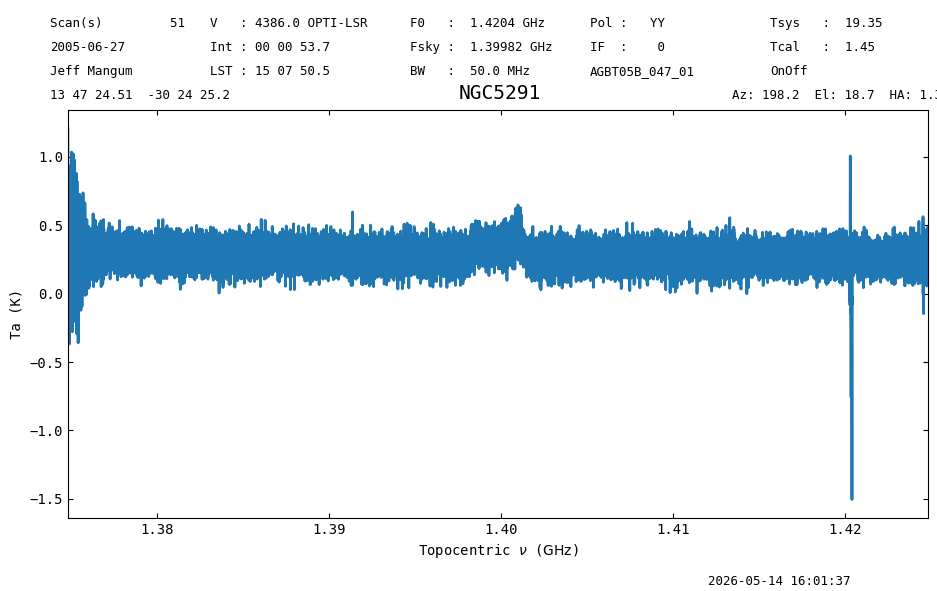

In [14]:
s2 = Spectrum.read(output_dir / "testwrite.ecsv", format="ecsv")
s2.plot();

In [15]:
# "https://www.gb.nrao.edu/dysh/example_data/onoff-L/gbtidl-data/onoff-L_gettp_156_intnum_0_HEL.ascii"
filename_ascii = dysh_data(example="onoff-L/gbtidl-data/onoff-L_gettp_156_intnum_0_HEL.ascii")
s3 = Spectrum.read(filename_ascii, format='gbtidl')

16:01:37.552 I url: http://www.gb.nrao.edu/dysh//example_data/onoff-L/gbtidl-data/onoff-L_gettp_156_intnum_0_HEL.ascii


Odd-1, did not find /bigdisk/data/gbt/dysh_data/example_data/onoff-L/gbtidl-data/onoff-L_gettp_156_intnum_0_HEL.ascii
onoff-L_gettp_156_intnum_0_HEL.ascii already downloaded


In [16]:
print(s3, "\n", s3.meta)

Spectrum (length=32768)
Flux=[3608710. 3553598. 3604808. ... 3523171. 3545982. 3474847.] ct,  mean=493422767.43425 ct
Spectral Axis=[1.42009237 1.42009166 1.42009094 ... 1.39665654 1.39665582
               1.39665511] GHz,  mean=1.40837 GHz 
 {'SCAN': 156, 'OBJECT': 'NGC2782', 'DATE-OBS': '2021-02-10 00:00:00.000', 'RA': np.float64(119.42083333333332), 'VELDEF': 'None-HEL', 'POL': 'YY', 'MJD-OBS': np.float64(59255.0)}


In [17]:
filename_ascii_gz = dysh_data(example="onoff-L/gbtidl-data/onoff-L_getps_152_RADI-HEL.ascii.gz")
s4 = Spectrum.read(filename_ascii_gz, format='gbtidl')

16:01:37.883 I url: http://www.gb.nrao.edu/dysh//example_data/onoff-L/gbtidl-data/onoff-L_getps_152_RADI-HEL.ascii.gz


Odd-1, did not find /bigdisk/data/gbt/dysh_data/example_data/onoff-L/gbtidl-data/onoff-L_getps_152_RADI-HEL.ascii.gz
onoff-L_getps_152_RADI-HEL.ascii.gz already downloaded


In [18]:
print(s4, "\n", s4.meta)

Spectrum (length=32768)
Flux=[-0.1042543   0.05250004  0.00432693 ... -0.05038555  0.03408394
       0.06139921] K,  mean=0.17345 K
Spectral Axis=[1281.15245599 1281.30342637 1281.45439674 ... 6227.69690405
               6227.84787443 6227.99884481] km / s,  mean=3754.57565 km / s 
 {'SCAN': 152, 'OBJECT': 'NGC2415', 'DATE-OBS': '2021-02-10 00:00:00.000', 'RA': np.float64(114.65624999999999), 'VELDEF': 'RADI-HEL', 'POL': 'YY', 'MJD-OBS': np.float64(59255.0)}


In [19]:
# set the rest frequency to the HI line
s4.rest_value = 1420405751.786 * u.Hz

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/traitlets/traitlets.py:1385: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
NavigationToolbar2WebAgg.__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  warn(


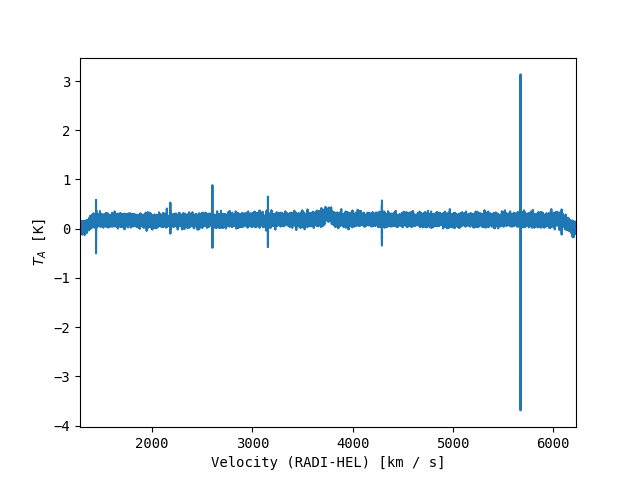

In [20]:
plt.figure()
plt.xlabel(f"Velocity ({s4.meta['VELDEF']}) [{s4.spectral_axis.unit}]")
plt.ylabel(f"$T_A$ [{s4.flux.unit}]")
plt.plot(s4.spectral_axis, s4.flux);

In [21]:
ps_scan_block.write(output_dir / "scanblock.fits", overwrite=True)

In [22]:
ps_scan_block_read = GBTFITSLoad(output_dir / "scanblock.fits")

In [23]:
ps_scan_block_read.summary()

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
51,NGC5291,4386.0,OnOff,1,1.420405,1,1,11,1,198.3431,18.6427


In [24]:
tp_read = ps_scan_block_read.gettp(scan=51, ifnum=0, plnum=0, fdnum=0)
print(f"Number of integrations: {tp_read[0].nint}")

16:01:38.724 I Using TSYS column


Number of integrations: 11


/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


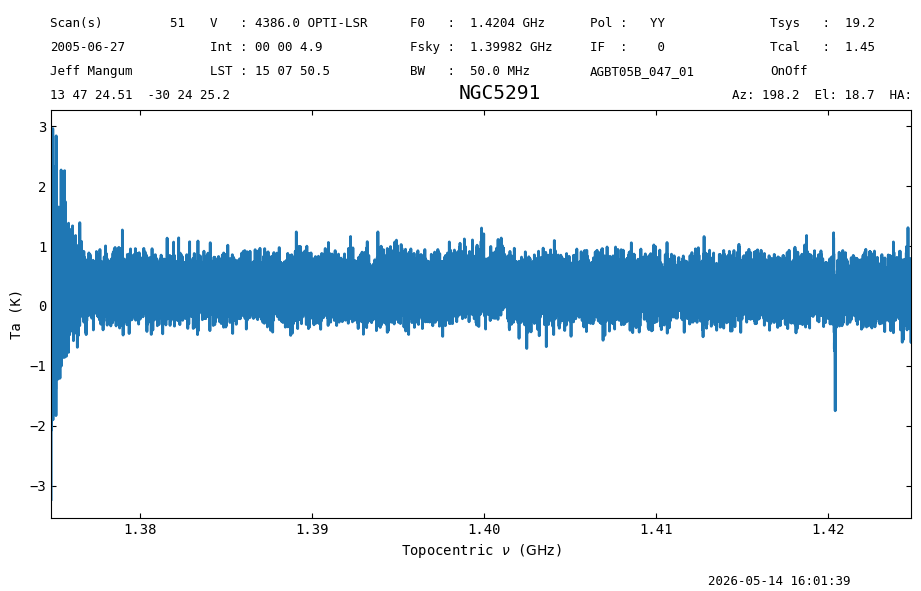

In [25]:
ta_read_0a = tp_read[0].getspec(0)
ta_read_0a.plot();

In [26]:
ta_read_0b = ps_scan_block_read.getspec(0)

/bigdisk/src/dysh/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2599: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*args, out=...)


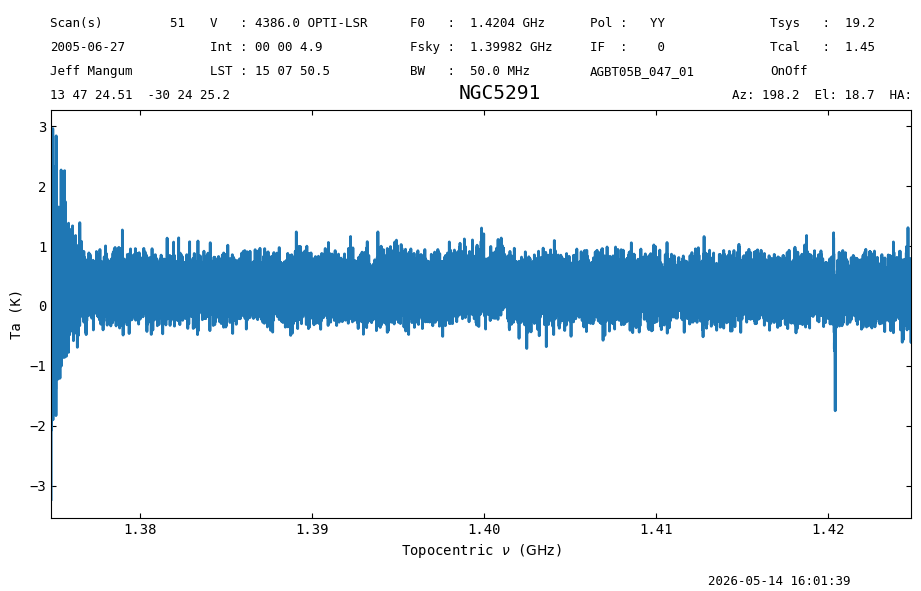

In [27]:
ta_read_0b.plot();

In [28]:
(ta_read_0a.data - ta_read_0b.data).sum()

np.float64(0.0)

In [29]:
sdfits.write(output_dir / "mydata.fits", plnum=1, 
             intnum=range(5), overwrite=True, multifile=False)

 ID    TAG    PLNUM   INTNUM   # SELECTED
--- --------- ----- ---------- ----------
  0 50d5da02e     1 range(0,5)         80


In [30]:
sdfits2 = GBTFITSLoad(output_dir / "mydata.fits")

In [31]:
sdfits2.summary()

SCAN,OBJECT,VELOCITY,PROC,PROCSEQN,RESTFREQ,# IF,# POL,# INT,# FEED,AZIMUTH,ELEVATION
51,NGC5291,4386.0,OnOff,1,1.420405,1,1,5,1,198.2327,18.6739
52,NGC5291,4386.0,OnOff,2,1.420405,1,1,5,1,198.8200,18.8193
53,NGC5291,4386.0,OnOff,1,1.420405,1,1,5,1,199.2207,18.3889
54,NGC5291,4386.0,OnOff,2,1.420405,1,1,5,1,199.8058,18.5264
55,NGC5291,4386.0,OnOff,1,1.420405,1,1,5,1,200.1952,18.0919
56,NGC5291,4386.0,OnOff,2,1.420405,1,1,5,1,200.7815,18.2213
57,NGC5291,4386.0,OnOff,1,1.420405,1,1,5,1,202.2201,17.4228
58,NGC5291,4386.0,OnOff,2,1.420405,1,1,5,1,202.8117,17.5334


In [32]:
ta_read_0a.check_stats(0.26165166 * u.K)

16:01:40.941 I rms is OK 
